<a href="https://colab.research.google.com/github/AlexTokarev85/-/blob/main/Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: Оценка и выбор промпта для генерации карточек товаров

## 🎯 Цель работы

Вы — маркетолог-аналитик в e-commerce компании. Копирайтеры не успевают писать описания для всех товаров, и нужно автоматизировать процесс с помощью LLM.

У вас есть:
- **Старый промпт** (baseline), который уже используется
- **3 новых промпта-кандидата**, которые могут работать лучше

**Ваша задача:**
1. Сгенерировать описания товаров всеми промптами
2. Создать LLM-судью для автоматической оценки
4. Оценить надёжность LLM-судьи через согласованность с человеческими оценками

---

## 📝 Что нужно сделать

В тетрадке есть **секции с заданиями** отмеченные `# TODO:` — их нужно выполнить самостоятельно.

### Обязательные части:
1. ✅ Дописать промпт для LLM-судьи
2. ✅ Реализовать расчёт Cohen's Kappa
3. ✅ Проанализировать результаты и сделать выводы



## 📚 Полезные ссылки

- [Cohen's Kappa объяснение](https://en.wikipedia.org/wiki/Cohen%27s_kappa)
- [LLM-as-Judge](https://habr.com/ru/articles/905728/)

## 🔧 Установка библиотек

In [ ]:
!pip install -q openai pandas numpy scipy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
from openai import OpenAI
import json
import time
from scipy import stats
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from typing import List, Dict
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 🔑 API ключ

Используйте DeepSeek API (дешево и доступно из России) или любую другую OpenAI-совместимую модель.

In [ ]:
# Вариант 1: DeepSeek (рекомендуется)
API_KEY = "your-api-key"  # Получить на https://platform.deepseek.com/ , если нет своего sk-798ed28ba3d7462abdc07aca39d43d7a
BASE_URL = "https://api.deepseek.com"
MODEL = "deepseek-chat"

# Вариант 2: OpenAI
# API_KEY = "your-openai-api-key"
# BASE_URL = "https://api.openai.com/v1"
# MODEL = "gpt-4o-mini"

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

print("✅ API клиент настроен")

✅ API клиент настроен


## 📦 Датасет товаров

Используем реалистичные товары из разных категорий.

In [ ]:
products_data = [
    {
        "id": 1,
        "name": "Беспроводные наушники Sony WH-1000XM5",
        "category": "Электроника",
        "price": 29990,
        "features": "Активное шумоподавление, 30 часов работы, Bluetooth 5.2, быстрая зарядка",
        "target_audience": "Меломаны, путешественники, офисные работники"
    },
    {
        "id": 2,
        "name": "Кофемашина DeLonghi Magnifica S",
        "category": "Бытовая техника",
        "price": 45900,
        "features": "Автоматическая кофемашина, встроенная кофемолка, 13 степеней помола, капучинатор",
        "target_audience": "Кофейные гурманы, домашнее использование"
    },
    {
        "id": 3,
        "name": "Беговые кроссовки Nike Air Zoom Pegasus 40",
        "category": "Спорт",
        "price": 12990,
        "features": "Амортизация React foam, вентилируемая сетка, поддержка свода стопы, для ежедневных пробежек",
        "target_audience": "Бегуны любого уровня, фитнес-энтузиасты"
    },
    {
        "id": 4,
        "name": "Смарт-часы Apple Watch Series 9",
        "category": "Электроника",
        "price": 39990,
        "features": "Датчик температуры, ЭКГ, измерение кислорода в крови, GPS, водонепроницаемость 50м",
        "target_audience": "Спортсмены, следящие за здоровьем, пользователи iPhone"
    },
    {
        "id": 5,
        "name": "Робот-пылесос Xiaomi Robot Vacuum S10+",
        "category": "Бытовая техника",
        "price": 34990,
        "features": "Мощность всасывания 4000Па, лазерная навигация, самоочистка, влажная уборка",
        "target_audience": "Занятые люди, владельцы домашних животных, большие квартиры"
    },
    {
        "id": 6,
        "name": "Электросамокат Ninebot KickScooter Max G30",
        "category": "Транспорт",
        "price": 47990,
        "features": "Запас хода 65км, максимальная скорость 25км/ч, IP54, дисковый тормоз",
        "target_audience": "Городские жители, экологичный транспорт, путь на работу"
    },
    {
        "id": 7,
        "name": "Массажное кресло Casada Betasonic II",
        "category": "Здоровье и красота",
        "price": 129990,
        "features": "3D массаж, нулевая гравитация, прогрев, 12 автопрограмм, массаж стоп",
        "target_audience": "Люди с болями в спине, стресс-релакс, премиум-сегмент"
    },
    {
        "id": 8,
        "name": "Игровое кресло DXRacer Master",
        "category": "Мебель",
        "price": 54990,
        "features": "Эргономика, регулировка 4D подлокотников, поясничная поддержка, искусственная кожа",
        "target_audience": "Геймеры, стримеры, офисные работники"
    },
    {
        "id": 9,
        "name": "Увлажнитель воздуха Dyson Pure Humidify+Cool",
        "category": "Климатическая техника",
        "price": 62990,
        "features": "Увлажнение + очистка воздуха, УФ-очистка воды, датчики качества воздуха, управление со смартфона",
        "target_audience": "Аллергики, семьи с детьми, сухой климат"
    },
    {
        "id": 10,
        "name": "Умная колонка Яндекс Станция Макс 2",
        "category": "Умный дом",
        "price": 24990,
        "features": "Алиса, мощный звук, управление умным домом, встроенный Zigbee-хаб, 10-дюймовый дисплей",
        "target_audience": "Пользователи умного дома, любители музыки, семьи"
    },
    {
        "id": 11,
        "name": "Мультиварка Redmond SkyCooker M92S",
        "category": "Кухонная техника",
        "price": 8990,
        "features": "50 автопрограмм, управление через приложение, мастершеф 3D-нагрев, 5 литров",
        "target_audience": "Занятые люди, начинающие повара, здоровое питание"
    },
    {
        "id": 12,
        "name": "Фитнес-браслет Xiaomi Mi Band 8 Pro",
        "category": "Электроника",
        "price": 6990,
        "features": "AMOLED дисплей, пульсометр 24/7, GPS, 150+ режимов тренировок, 14 дней работы",
        "target_audience": "Начинающие спортсмены, контроль здоровья, бюджетный сегмент"
    },
    {
        "id": 13,
        "name": "Электрогриль Tefal OptiGrill Elite",
        "category": "Кухонная техника",
        "price": 19990,
        "features": "Автоматические режимы для 12 продуктов, индикатор готовности, съёмные панели, 2000Вт",
        "target_audience": "Любители гриля, здоровое питание, малогабаритные кухни"
    },
    {
        "id": 14,
        "name": "Портативная колонка JBL Charge 5",
        "category": "Аудио",
        "price": 13990,
        "features": "Водонепроницаемость IP67, 20 часов работы, powerbank функция, PartyBoost",
        "target_audience": "Путешественники, пикники, любители музыки на природе"
    },
    {
        "id": 15,
        "name": "Электросушилка для обуви Xiaomi Sothing",
        "category": "Аксессуары",
        "price": 2490,
        "features": "УФ-стерилизация, 3 режима температуры, таймер, озонирование, для любой обуви",
        "target_audience": "Спортсмены, дождливый климат, семьи с детьми"
    }
]

df_products = pd.DataFrame(products_data)
print(f"✅ Загружено {len(df_products)} товаров")
df_products.head()

✅ Загружено 15 товаров


,id,name,category,price,features,target_audience
0,1,Беспроводные наушники Sony WH-1000XM5,Электроника,29990,"Активное шумоподавление, 30 часов работы, Blue...","Меломаны, путешественники, офисные работники"
1,2,Кофемашина DeLonghi Magnifica S,Бытовая техника,45900,"Автоматическая кофемашина, встроенная кофемолк...","Кофейные гурманы, домашнее использование"
2,3,Беговые кроссовки Nike Air Zoom Pegasus 40,Спорт,12990,"Амортизация React foam, вентилируемая сетка, п...","Бегуны любого уровня, фитнес-энтузиасты"
3,4,Смарт-часы Apple Watch Series 9,Электроника,39990,"Датчик температуры, ЭКГ, измерение кислорода в...","Спортсмены, следящие за здоровьем, пользовател..."
4,5,Робот-пылесос Xiaomi Robot Vacuum S10+,Бытовая техника,34990,"Мощность всасывания 4000Па, лазерная навигация...","Занятые люди, владельцы домашних животных, бол..."


## 🎭 Промпты для генерации описаний(промты можете менять на свое усмотрение)

У нас есть один старый промпт (baseline) и три новых варианта.

In [ ]:
PROMPTS = {
    # Baseline: сухой и информативный (как пишут большинство)
    "baseline": """Напиши описание товара для маркетплейса.

Товар: {name}
Цена: {price} руб.
Характеристики: {features}

Опиши товар в 2-3 предложениях. Перечисли основные характеристики и укажи, для чего подходит.""",

    # Вариант A: Сторителлинг + проблема-решение
    "variant_a": """Ты копирайтер, который продаёт через истории. Напиши описание товара, начав с проблемы покупателя.

Товар: {name}
Цена: {price} руб.
Характеристики: {features}
Целевая аудитория: {target_audience}

Структура (2-3 предложения, ~50 слов):
1. Начни с боли/проблемы читателя ("Знакомо, когда...", "Устали от...")
2. Покажи, как товар решает эту проблему
3. Закончи результатом/трансформацией

Пиши от второго лица (ты/вы). Только текст описания.""",

    # Вариант B: FOMO + социальное доказательство
    "variant_b": """Создай описание товара с эффектом срочности и социального доказательства.

Товар: {name}
Цена: {price} руб.
Характеристики: {features}
Для кого: {target_audience}

Используй приёмы:
- Упомяни популярность ("тысячи покупателей", "хит продаж", "выбор профессионалов")
- Создай ощущение эксклюзивности или ограниченности
- Подчеркни, что покупатель получит преимущество перед другими

2-3 предложения, до 50 слов. Тон уверенный, но не агрессивный. Только текст.""",

    # Вариант C: Провокация + нестандартный угол
    "variant_c": """Напиши описание товара в провокационном стиле. Удиви читателя, сломай шаблон.

Товар: {name}
Цена: {price} руб.
Характеристики: {features}
Аудитория: {target_audience}

Правила:
- Начни с неожиданного утверждения или вопроса
- Используй контраст или парадокс
- Можно немного иронии или дерзости
- НЕ используй клише ("идеальный", "уникальный", "незаменимый")

2-3 предложения, до 50 слов. Цепляй с первого слова. Только текст описания."""
}

print("✅ Определены 4 промпта: baseline + 3 варианта")

✅ Определены 4 промпта: baseline + 3 варианта


## 🤖 Функция для генерации текстов

In [ ]:
def generate_description(product: Dict, prompt_template: str, model: str = MODEL) -> str:
    """Генерирует описание товара используя заданный промпт."""
    prompt = prompt_template.format(**product)

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "user", "content": prompt}
            ],
            temperature=0.7,
            max_tokens=200
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"Ошибка генерации для товара {product['id']}: {e}")
        return ""

def generate_all_descriptions(df: pd.DataFrame, prompts: Dict) -> pd.DataFrame:
    """Генерирует описания для всех товаров всеми промптами."""
    results = df.copy()

    for prompt_name, prompt_template in prompts.items():
        print(f"\n📝 Генерирую описания с промптом: {prompt_name}")
        descriptions = []

        for idx, product in df.iterrows():
            desc = generate_description(product.to_dict(), prompt_template)
            descriptions.append(desc)
            print(f"  [{idx+1}/{len(df)}] {product['name'][:40]}...")
            time.sleep(0.5)  # Чтобы не превысить rate limit

        results[f"description_{prompt_name}"] = descriptions

    return results

print("✅ Функции генерации готовы")

✅ Функции генерации готовы


## 🚀 Генерация описаний

**Внимание:** Это займёт несколько минут. Будет сгенерировано 15 товаров × 4 промпта = 60 описаний.

In [ ]:
# Запускаем генерацию
df_results = generate_all_descriptions(df_products, PROMPTS)

print("\n✅ Генерация завершена!")
print(f"Создано описаний: {len(df_results) * 4}")


📝 Генерирую описания с промптом: baseline
  [1/15] Беспроводные наушники Sony WH-1000XM5...
  [2/15] Кофемашина DeLonghi Magnifica S...
  [3/15] Беговые кроссовки Nike Air Zoom Pegasus ...
  [4/15] Смарт-часы Apple Watch Series 9...
  [5/15] Робот-пылесос Xiaomi Robot Vacuum S10+...
  [6/15] Электросамокат Ninebot KickScooter Max G...
  [7/15] Массажное кресло Casada Betasonic II...
  [8/15] Игровое кресло DXRacer Master...
  [9/15] Увлажнитель воздуха Dyson Pure Humidify+...
  [10/15] Умная колонка Яндекс Станция Макс 2...
  [11/15] Мультиварка Redmond SkyCooker M92S...
  [12/15] Фитнес-браслет Xiaomi Mi Band 8 Pro...
  [13/15] Электрогриль Tefal OptiGrill Elite...
  [14/15] Портативная колонка JBL Charge 5...
  [15/15] Электросушилка для обуви Xiaomi Sothing...

📝 Генерирую описания с промптом: variant_a
  [1/15] Беспроводные наушники Sony WH-1000XM5...
  [2/15] Кофемашина DeLonghi Magnifica S...
  [3/15] Беговые кроссовки Nike Air Zoom Pegasus ...
  [4/15] Смарт-часы Apple Watch Se

## 👀 Посмотрим на примеры

In [ ]:
# Выберем 5 случайных товаров для ручной оценки
np.random.seed(42)
sample_indices = np.random.choice(df_results.index, size=5, replace=False)
df_manual_eval = df_results.loc[sample_indices].copy()

print("📋 Оцените описания для следующих товаров:\n")
for idx in sample_indices:
    print(f"  {idx+1}. {df_results.loc[idx, 'name']}")

📋 Оцените описания для следующих товаров:

  10. Умная колонка Яндекс Станция Макс 2
  12. Фитнес-браслет Xiaomi Mi Band 8 Pro
  1. Беспроводные наушники Sony WH-1000XM5
  14. Портативная колонка JBL Charge 5
  6. Электросамокат Ninebot KickScooter Max G30


In [ ]:
# Выберем товар для демонстрации
# замени 0 в idx на index своего примера
idx = 0
sample_product = df_results.iloc[idx - 1]

print(f"🎧 Товар: {sample_product['name']}")
print(f"💰 Цена: {sample_product['price']} руб.\n")

for prompt_name in PROMPTS.keys():
    print(f"\n{'='*60}")
    print(f"📄 Промпт: {prompt_name.upper()}")
    print(f"{'='*60}")
    print(sample_product[f"description_{prompt_name}"])

🎧 Товар: Электросушилка для обуви Xiaomi Sothing
💰 Цена: 2490 руб.


📄 Промпт: BASELINE
Конечно, вот несколько вариантов описания, от короткого до более маркетингового.

### Вариант 1 (Краткий и по делу)

Электросушилка Xiaomi Sothing быстро и эффективно сушит обувь любой сезонности, уничтожая при этом бактерии и неприятные запахи. Оснащена УФ-стерилизацией, функцией озонирования и тремя температурными режимами для бережного ухода. Удобный таймер позволяет настроить работу под ваши нужды.

### Вариант 2 (С акцентом на пользу)

Забудьте о влажной и холодной обуви! Умная сушилка Xiaomi Sothing не только быстро высушит кроссовки, сапоги или туфли, но и позаботится о здоровье ваших ног. Б

📄 Промпт: VARIANT_A
Знакомо, когда сырая обувь портит всё настроение и грозит простудами? Эта электросушилка с УФ-стерилизацией и озонированием не просто быстро сушит, но и уничтожает бактерии. Вы забудете о сырости и дискомфорте, наслаждаясь ощущением свежей и тёплой обуви каждый день.

📄 Промпт: VARIAN

## 🎯 ЗАДАНИЕ 1: Ручная оценка (Human Evaluation)

Сначала вы сами оцените качество описаний для небольшой выборки товаров. Это нужно для:
1. Понимания, что такое "хорошее" описание
2. Проверки согласованности с LLM-судьёй позже

### Критерии оценки (шкала 1-5):
- **5** — Отличное описание: продающее, информативное, без ошибок
- **4** — Хорошее: выполняет задачу, небольшие недочёты
- **3** — Среднее: не плохо, но и не впечатляет
- **2** — Слабое: скучно, слишком общее или есть проблемы
- **1** — Плохое: бесполезное, с ошибками или нерелевантное

### 📝 Введите ваши оценки

Прочитайте описания выше и поставьте оценки от 1 до 5 для каждого промпта.   
Это будут ваши honeypots - ответы, которые мы считаем истинными.

In [ ]:
# TODO: Заполните ваши оценки (от 1 до 5)
# Формат: список из 5 элементов, где каждый элемент — dict с оценками для всех промптов

manual_scores = [
    # Товар 1
    {
        "baseline": 1,    # TODO: ваша оценка
        "variant_a": 4,   # TODO: ваша оценка
        "variant_b": 4,   # TODO: ваша оценка
        "variant_c": 5    # TODO: ваша оценка
    },
    # Товар 2
    {
        "baseline": None,  # TODO: ваша оценка
        "variant_a": None,
        "variant_b": None,
        "variant_c": None
    },
    # Товар 3
    {
        "baseline": None,  # TODO: ваша оценка
        "variant_a": None,
        "variant_b": None,
        "variant_c": None
    },
    # Товар 4
    {
        "baseline": None,  # TODO: ваша оценка
        "variant_a": None,
        "variant_b": None,
        "variant_c": None
    },
    # Товар 5
    {
        "baseline": None,  # TODO: ваша оценка
        "variant_a": None,
        "variant_b": None,
        "variant_c": None
    }
]

# Сохраняем оценки
for i, (idx, scores) in enumerate(zip(sample_indices, manual_scores)):
    for prompt_name in PROMPTS.keys():
        df_manual_eval.loc[idx, f"human_score_{prompt_name}"] = scores[prompt_name]

print("✅ Ручные оценки сохранены")

✅ Ручные оценки сохранены


## 🤖 ЗАДАНИЕ 2: Создание LLM-судьи

Теперь создадим автоматического судью, который будет оценивать качество описаний.

### ✏️ ВАША ЗАДАЧА:
Допишите промпт для LLM-судьи в переменной `JUDGE_PROMPT` ниже.

**Требования к промпту:**
1. Чёткие критерии оценки
2. Примеры хороших/плохих описаний (опционально)
3. Инструкция возвращать только число от 1 до 5
4. Учёт специфики маркетплейсов

In [ ]:
# TODO: Допишите промпт для судьи
JUDGE_PROMPT = """Ты — эксперт по e-commerce и копирайтингу. Оцени качество описания товара для маркетплейса.

**Товар:** {name}
**Цена:** {price} руб.
**Характеристики:** {features}
**Целевая аудитория:** {target_audience}

**Описание для оценки:**
{description}

---

**Критерии оценки:**

TODO: Добавьте критерии оценки (например: информативность, продающий эффект, читаемость, соответствие аудитории)

**Шкала оценки:**
- 5: [TODO: опишите, что такое отличное описание]
- 4: [TODO: опишите хорошее описание]
- 3: [TODO: опишите среднее описание]
- 2: [TODO: опишите слабое описание]
- 1: [TODO: опишите плохое описание]

**Формат ответа:**
Верни ТОЛЬКО одну цифру от 1 до 5, без объяснений.
"""

print("⚠️ TODO: Допишите промпт для судьи выше!")

⚠️ TODO: Допишите промпт для судьи выше!


### Функция для LLM-судьи

In [ ]:
def llm_judge(product: Dict, description: str, judge_prompt: str = JUDGE_PROMPT) -> int:
    """LLM оценивает качество описания товара."""
    prompt = judge_prompt.format(
        name=product['name'],
        price=product['price'],
        features=product['features'],
        target_audience=product['target_audience'],
        description=description
    )

    try:
        response = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.3,
            max_tokens=10
        )

        score_text = response.choices[0].message.content.strip()
        # Извлекаем первую цифру из ответа
        score = int(''.join(filter(str.isdigit, score_text))[0])
        return max(1, min(5, score))  # Ограничиваем 1-5
    except Exception as e:
        print(f"Ошибка судьи: {e}")
        return 3  # Нейтральная оценка при ошибке

print("✅ Функция LLM-судьи готова")

✅ Функция LLM-судьи готова


### Запуск автоматической оценки

In [ ]:
# Оцениваем ВСЕ описания LLM-судьёй
print("🤖 Запуск автоматической оценки...\n")

for prompt_name in PROMPTS.keys():
    print(f"Оцениваю промпт: {prompt_name}")
    scores = []

    for idx, row in df_results.iterrows():
        description = row[f"description_{prompt_name}"]
        score = llm_judge(row.to_dict(), description)
        scores.append(score)
        print(f"  [{idx+1}/{len(df_results)}] Оценка: {score}")
        time.sleep(0.1)

    df_results[f"llm_score_{prompt_name}"] = scores

print("\n✅ Автоматическая оценка завершена!")

🤖 Запуск автоматической оценки...

Оцениваю промпт: baseline
  [1/15] Оценка: 4
  [2/15] Оценка: 3
  [3/15] Оценка: 3
  [4/15] Оценка: 3
  [5/15] Оценка: 3
  [6/15] Оценка: 3
  [7/15] Оценка: 2
  [8/15] Оценка: 3
  [9/15] Оценка: 4
  [10/15] Оценка: 3
  [11/15] Оценка: 4
  [12/15] Оценка: 4
  [13/15] Оценка: 3
  [14/15] Оценка: 4
  [15/15] Оценка: 3
Оцениваю промпт: variant_a
  [1/15] Оценка: 4
  [2/15] Оценка: 3
  [3/15] Оценка: 4
  [4/15] Оценка: 2
  [5/15] Оценка: 4
  [6/15] Оценка: 4
  [7/15] Оценка: 4
  [8/15] Оценка: 3
  [9/15] Оценка: 3
  [10/15] Оценка: 4
  [11/15] Оценка: 4
  [12/15] Оценка: 3
  [13/15] Оценка: 4
  [14/15] Оценка: 4
  [15/15] Оценка: 3
Оцениваю промпт: variant_b
  [1/15] Оценка: 2
  [2/15] Оценка: 2
  [3/15] Оценка: 2
  [4/15] Оценка: 2
  [5/15] Оценка: 2
  [6/15] Оценка: 3
  [7/15] Оценка: 2
  [8/15] Оценка: 2
  [9/15] Оценка: 2
  [10/15] Оценка: 3
  [11/15] Оценка: 2
  [12/15] Оценка: 2
  [13/15] Оценка: 2
  [14/15] Оценка: 2
  [15/15] Оценка: 2
Оцениваю про

In [ ]:
df_results

,id,name,category,price,features,target_audience,description_baseline,description_variant_a,description_variant_b,description_variant_c,llm_score_baseline,llm_score_variant_a,llm_score_variant_b,llm_score_variant_c
0,1,Беспроводные наушники Sony WH-1000XM5,Электроника,29990,"Активное шумоподавление, 30 часов работы, Blue...","Меломаны, путешественники, офисные работники","Конечно, вот несколько вариантов описания, от ...","Знакомо, когда шум метро или офиса не дает сос...",Хит продаж среди тысяч меломанов! Легендарные ...,Тишина — это новый хайп. Хватит слушать чужой ...,4,4,2,4
1,2,Кофемашина DeLonghi Magnifica S,Бытовая техника,45900,"Автоматическая кофемашина, встроенная кофемолк...","Кофейные гурманы, домашнее использование","Конечно, вот несколько вариантов описания, от ...","Знакомо, когда утром нет времени на сложный ри...","DeLonghi Magnifica S — хит продаж, который уже...","Ты всё ещё платишь за кофе, который готовит кт...",3,3,2,2
2,3,Беговые кроссовки Nike Air Zoom Pegasus 40,Спорт,12990,"Амортизация React foam, вентилируемая сетка, п...","Бегуны любого уровня, фитнес-энтузиасты","Конечно, вот несколько вариантов описания для ...","Знакомо, когда каждая пробежка отзывается диск...","Nike Air Zoom Pegasus 40 — хит продаж, который...","Ты платишь 13 тысяч, чтобы убежать от себя. Эт...",3,4,2,2
3,4,Смарт-часы Apple Watch Series 9,Электроника,39990,"Датчик температуры, ЭКГ, измерение кислорода в...","Спортсмены, следящие за здоровьем, пользовател...","Конечно, вот несколько вариантов описания для ...","Знакомо, когда не знаешь, как организм отклика...",Apple Watch Series 9 — хит продаж и выбор тыся...,Ты всё ещё меряешь здоровье шагами? Пора взрос...,3,2,2,2
4,5,Робот-пылесос Xiaomi Robot Vacuum S10+,Бытовая техника,34990,"Мощность всасывания 4000Па, лазерная навигация...","Занятые люди, владельцы домашних животных, бол...","Конечно, вот несколько вариантов описания для ...","Знакомо, когда после долгого дня дома ждут не ...",Хит продаж! Xiaomi S10+ с мощностью 4000 Па — ...,"Твоя жизнь слишком ценна, чтобы тратить её на ...",3,4,2,4
5,6,Электросамокат Ninebot KickScooter Max G30,Транспорт,47990,"Запас хода 65км, максимальная скорость 25км/ч,...","Городские жители, экологичный транспорт, путь ...","Конечно, вот несколько вариантов описания для ...","Знакомо, когда стоишь в пробках, опаздывая на ...",Хит продаж этого сезона! Тысячи горожан уже вы...,Ты всё ещё стоишь в пробке? Как древний римлян...,3,4,3,4
6,7,Массажное кресло Casada Betasonic II,Здоровье и красота,129990,"3D массаж, нулевая гравитация, прогрев, 12 авт...","Люди с болями в спине, стресс-релакс, премиум-...","Конечно, вот несколько вариантов описания для ...","Знакомо, когда к концу дня спина ноет от напря...",Casada Betasonic II — выбор тысяч для снятия б...,"Ты платишь психологу, а он не разминает твои з...",2,4,2,2
7,8,Игровое кресло DXRacer Master,Мебель,54990,"Эргономика, регулировка 4D подлокотников, пояс...","Геймеры, стримеры, офисные работники","Конечно, вот описание для маркетплейса:\n\nDXR...","Знакомо, когда после долгой игры или рабочего ...","Этот хит продаж, который выбирают тысячи гейме...","Ты платишь за диван, который убивает твои побе...",3,3,2,2
8,9,Увлажнитель воздуха Dyson Pure Humidify+Cool,Климатическая техника,62990,"Увлажнение + очистка воздуха, УФ-очистка воды,...","Аллергики, семьи с детьми, сухой климат","Конечно, вот описание для маркетплейса:\n\n**К...","Знакомо, когда сухой воздух мешает спать, а пы...",Хит продаж среди тысяч семей. Последняя партия...,Ваш воздух — это помойка. Дышать этим — соглаш...,4,3,2,2
9,10,Умная колонка Яндекс Станция Макс 2,Умный дом,24990,"Алиса, мощный звук, управление умным домом, вс...","Пользователи умного дома, любители музыки, семьи","Конечно, вот несколько вариантов описания для ...","Знакомо, когда вместо слаженного умного дома п...",Хит продаж! Тысячи семей уже выбрали Яндекс Ст...,Забудьте о колонках. Это ваш личный диспетчер ...,3,4,3,3


## 📊 Визуализация оценок

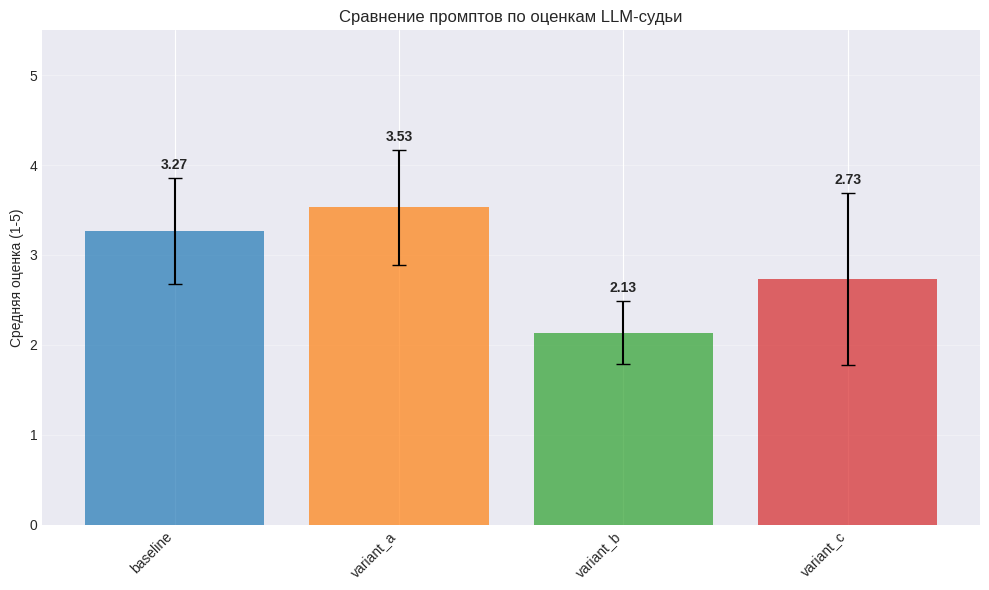

In [ ]:
# Сравнение средних оценок по промптам
fig, ax = plt.subplots(figsize=(10, 6))

prompt_names = list(PROMPTS.keys())
mean_scores = [df_results[f"llm_score_{p}"].mean() for p in prompt_names]
std_scores = [df_results[f"llm_score_{p}"].std() for p in prompt_names]

x_pos = np.arange(len(prompt_names))
ax.bar(x_pos, mean_scores, yerr=std_scores, capsize=5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_xticks(x_pos)
ax.set_xticklabels(prompt_names, rotation=45, ha='right')
ax.set_ylabel('Средняя оценка (1-5)')
ax.set_title('Сравнение промптов по оценкам LLM-судьи')
ax.set_ylim([0, 5.5])
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, (score, std) in enumerate(zip(mean_scores, std_scores)):
    ax.text(i, score + std + 0.1, f"{score:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 🔍 ЗАДАНИЕ 3: Оценка согласованности (Inter-rater Agreement)

Теперь проверим, насколько LLM-судья согласен с вашими ручными оценками.

### ✏️ ВАША ЗАДАЧА:
Реализуйте расчёт **Cohen's Kappa** для измерения согласованности между вашими оценками и оценками LLM.

**Справка:**
- Cohen's Kappa = (Po - Pe) / (1 - Pe)
- Po = наблюдаемое согласие
- Pe = ожидаемое согласие при случайности
- Можно использовать `sklearn.metrics.cohen_kappa_score()`

**Интерпретация:**
- < 0: Согласие хуже случайного
- 0.0-0.20: Слабое согласие  
- 0.21-0.40: Умеренное
- 0.41-0.60: Среднее
- 0.61-0.80: Хорошее
- 0.81-1.00: Почти полное

In [ ]:
df_manual_eval

,id,name,category,price,features,target_audience,description_baseline,description_variant_a,description_variant_b,description_variant_c,human_score_baseline,human_score_variant_a,human_score_variant_b,human_score_variant_c
9,10,Умная колонка Яндекс Станция Макс 2,Умный дом,24990,"Алиса, мощный звук, управление умным домом, вс...","Пользователи умного дома, любители музыки, семьи","Конечно, вот несколько вариантов описания для ...","Знакомо, когда вместо слаженного умного дома п...",Хит продаж! Тысячи семей уже выбрали Яндекс Ст...,Забудьте о колонках. Это ваш личный диспетчер ...,1.0,4.0,4.0,5.0
11,12,Фитнес-браслет Xiaomi Mi Band 8 Pro,Электроника,6990,"AMOLED дисплей, пульсометр 24/7, GPS, 150+ реж...","Начинающие спортсмены, контроль здоровья, бюдж...","Конечно, вот несколько вариантов описания для ...","Знакомо, когда не знаешь, с чего начать тренир...","Хит продаж, который выбрали тысячи! Xiaomi Mi ...","Ты платишь тысячи за абонемент, который пылитс...",NaN,NaN,NaN,NaN
0,1,Беспроводные наушники Sony WH-1000XM5,Электроника,29990,"Активное шумоподавление, 30 часов работы, Blue...","Меломаны, путешественники, офисные работники","Конечно, вот несколько вариантов описания, от ...","Знакомо, когда шум метро или офиса не дает сос...",Хит продаж среди тысяч меломанов! Легендарные ...,Тишина — это новый хайп. Хватит слушать чужой ...,NaN,NaN,NaN,NaN
13,14,Портативная колонка JBL Charge 5,Аудио,13990,"Водонепроницаемость IP67, 20 часов работы, pow...","Путешественники, пикники, любители музыки на п...","Конечно, вот несколько вариантов описания для ...","Знакомо, когда любимый трек прерывается на пик...","JBL Charge 5 — хит продаж, который выбирают ты...","Что, если ваша колонка устала от вашей гостино...",NaN,NaN,NaN,NaN
5,6,Электросамокат Ninebot KickScooter Max G30,Транспорт,47990,"Запас хода 65км, максимальная скорость 25км/ч,...","Городские жители, экологичный транспорт, путь ...","Конечно, вот несколько вариантов описания для ...","Знакомо, когда стоишь в пробках, опаздывая на ...",Хит продаж этого сезона! Тысячи горожан уже вы...,Ты всё ещё стоишь в пробке? Как древний римлян...,NaN,NaN,NaN,NaN


In [ ]:
# TODO: Реализуйте расчёт Cohen's Kappa

def calculate_agreement(df: pd.DataFrame, prompts: List[str], df_with_llm_scores: pd.DataFrame = None) -> Dict:
    """
    Рассчитывает метрики согласованности между человеческими и LLM оценками.

    Args:
        df: DataFrame с человеческими оценками (df_manual_eval)
        prompts: список названий промптов
        df_with_llm_scores: DataFrame с LLM оценками (df_results). Если None, ищет в df.

    Returns:
        Dict с метриками: cohen_kappa, accuracy, mean_diff
    """
    results = {}

    # Если LLM оценки в отдельном датафрейме - добавляем их
    if df_with_llm_scores is not None:
        for prompt_name in prompts:
            llm_col = f"llm_score_{prompt_name}"
            if llm_col in df_with_llm_scores.columns and llm_col not in df.columns:
                df[llm_col] = df_with_llm_scores.loc[df.index, llm_col]

    for prompt_name in prompts:
        human_col = f"human_score_{prompt_name}"
        llm_col = f"llm_score_{prompt_name}"

        # Проверяем наличие столбцов
        if human_col not in df.columns:
            print(f"⚠️ Столбец {human_col} не найден")
            continue
        if llm_col not in df.columns:
            print(f"⚠️ Столбец {llm_col} не найден. Убедитесь, что LLM-судья был запущен.")
            continue

        # Получаем оценки (только там, где есть ручные)
        mask = df[human_col].notna()
        human_scores = df.loc[mask, human_col].astype(int)
        llm_scores = df.loc[mask, llm_col].astype(int)

        if len(human_scores) == 0:
            print(f"⚠️ Нет ручных оценок для {prompt_name}")
            continue

        # TODO: Рассчитайте Cohen's Kappa
        kappa = cohen_kappa_score(human_scores, llm_scores)

        # TODO: Рассчитайте точность (accuracy) - процент полных совпадений
        accuracy = (human_scores == llm_scores).mean()

        # TODO: Рассчитайте среднюю абсолютную разницу оценок
        mean_diff = np.abs(human_scores - llm_scores).mean()

        results[prompt_name] = {
            "kappa": kappa,
            "accuracy": accuracy,
            "mean_diff": mean_diff
        }

    return results

# Вызываем функцию, передавая df_results для получения LLM оценок
agreement_results = calculate_agreement(df_manual_eval, list(PROMPTS.keys()), df_results)

# Выводим результаты
print("\n📊 СОГЛАСОВАННОСТЬ ЧЕЛОВЕКА И LLM-СУДЬИ\n")
print("="*70)
for prompt_name, metrics in agreement_results.items():
    print(f"\n{prompt_name.upper()}:")
    print(f"  Cohen's Kappa:  {metrics['kappa']:.3f}")
    print(f"  Accuracy:       {metrics['accuracy']:.1%}")
    print(f"  Mean |diff|:    {metrics['mean_diff']:.2f}")


📊 СОГЛАСОВАННОСТЬ ЧЕЛОВЕКА И LLM-СУДЬИ


BASELINE:
  Cohen's Kappa:  0.000
  Accuracy:       0.0%
  Mean |diff|:    2.00

VARIANT_A:
  Cohen's Kappa:  nan
  Accuracy:       100.0%
  Mean |diff|:    0.00

VARIANT_B:
  Cohen's Kappa:  0.000
  Accuracy:       0.0%
  Mean |diff|:    1.00

VARIANT_C:
  Cohen's Kappa:  0.000
  Accuracy:       0.0%
  Mean |diff|:    2.00


## 🤖 ЗАДАНИЕ 3: Анализ

### 📝 Анализ согласованности

**TODO: Ответьте на вопросы:**

1. Какой уровень согласованности вы получили? Можно ли доверять LLM-судье?
2. Для какого промпта согласие выше/ниже всего? Почему?
3. Посмотрите на примеры, где оценки сильно различаются. В чём причина разногласий?

In [ ]:
# Пример кода для поиска разногласий:
for prompt_name in PROMPTS.keys():
    human_col = f"human_score_{prompt_name}"
    llm_col = f"llm_score_{prompt_name}"

    # Находим случаи с большим расхождением (>=2 балла)
    mask = df_manual_eval[human_col].notna()
    disagreements = df_manual_eval[mask][
        abs(df_manual_eval[human_col] - df_manual_eval[llm_col]) >= 2
    ]

    if len(disagreements) > 0:
        print(f"\n⚠️ Сильные разногласия для {prompt_name}:")
        for idx, row in disagreements.iterrows():
            print(f"\nТовар: {row['name']}")
            print(f"Описание: {row[f'description_{prompt_name}']}")
            print(f"Ваша оценка: {int(row[human_col])} | LLM оценка: {int(row[llm_col])}")


⚠️ Сильные разногласия для baseline:

Товар: Умная колонка Яндекс Станция Макс 2
Описание: Конечно, вот несколько вариантов описания для маркетплейса:

### Вариант 1 (Краткий и по делу)

Яндекс Станция Макс 2 — это умная колонка с 10-дюймовым экраном и мощным звуком, которая станет вашим главным помощником. Управляйте умным домом голосом через Алису без дополнительных устройств благодаря встроенному Zigbee-хабу. Идеально подходит для просмотра видео, прослушивания музыки и контроля над всей домашней техникой.

### Вариант 2 (С акцентом на возможности)

Превратите квартиру в умный дом с Яндекс Станцией Макс 2! Наслаждайтесь кристально чистым звуком, смотрите фильмы на ярком 10-дюймовом экране
Ваша оценка: 1 | LLM оценка: 3

⚠️ Сильные разногласия для variant_c:

Товар: Умная колонка Яндекс Станция Макс 2
Описание: Забудьте о колонках. Это ваш личный диспетчер в мире, где экран подчиняется звуку. Командуйте голосом, пока мощный звук заполняет пространство. Алиса уже не просто слушает — 